In [ ]:
!pip install xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

In [ ]:
df = pd.read_csv("/content/cleaned_retail_inventory.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Price,Units Sold,Inventory Level,Discount,Competitor Pricing,Year,Month,Day,Total Sales
0,2022-01-01,S001,P0001,Groceries,North,33.50,127,231,20,29.69,2022,1,1,4254.50
1,2022-01-01,S001,P0002,Toys,South,63.01,150,204,20,66.16,2022,1,1,9451.50
2,2022-01-01,S001,P0003,Toys,West,27.99,65,102,10,31.32,2022,1,1,1819.35
3,2022-01-01,S001,P0004,Toys,North,32.72,61,469,10,34.74,2022,1,1,1995.92
4,2022-01-01,S001,P0005,Electronics,East,73.64,14,166,0,68.95,2022,1,1,1030.96


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.weekday

In [ ]:
X = df[[
    "Price",
    "Inventory Level",
    "Month",
    "Weekday"
]]

y = df["Units Sold"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
lgb_model = lgb.LGBMRegressor(n_estimators=100)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001858 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 526
[LightGBM] [Info] Number of data points in the train set: 58480, number of used features: 4
[LightGBM] [Info] Start training from score 136.747623


In [ ]:
print("----- XGBoost -----")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2:", r2_score(y_test, y_pred_xgb))

print("\n----- LightGBM -----")
print("MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lgb)))
print("R2:", r2_score(y_test, y_pred_lgb))

----- XGBoost -----
MAE: 69.27326202392578
RMSE: 89.17958039032114
R2: 0.3282751441001892

----- LightGBM -----
MAE: 69.02181218962868
RMSE: 88.38487912944456
R2: 0.34019356389712674


In [ ]:
df["ML_Price"] = df["Price"] * 1.10

In [ ]:
X_new = df[[
    "ML_Price",
    "Inventory Level",
    "Month",
    "Weekday"
]].copy()

X_new.rename(columns={"ML_Price": "Price"}, inplace=True)

In [ ]:
df["Predicted_Units"] = xgb_model.predict(X_new)

In [ ]:
df["Predicted_Units_LGB"] = lgb_model.predict(X_new)

In [ ]:
df["Original_Revenue"] = df["Price"].astype(float) * df["Units Sold"].astype(float)

if "Dynamic_Price" not in df.columns:
    print("Dynamic_Price not found → using original price as fallback")
    df["Dynamic_Price"] = df["Price"]

df["Rule_Revenue"] = df["Dynamic_Price"].astype(float) * df["Units Sold"].astype(float)

if "Predicted_Units" not in df.columns:
    raise ValueError("Predicted_Units not found. Run Step 11 first.")

df["ML_Revenue"] = df["ML_Price"].astype(float) * df["Predicted_Units"].astype(float)

In [ ]:
df["ML_Revenue_LGB"] = df["ML_Price"] * df["Predicted_Units_LGB"]

In [ ]:
original_revenue = df["Original_Revenue"].sum()
rule_revenue = df["Rule_Revenue"].sum()
ml_revenue_xgb = df["ML_Revenue"].sum()
ml_revenue_lgb = df["ML_Revenue_LGB"].sum()

print("Original Revenue:", original_revenue)
print("Rule-Based Revenue:", rule_revenue)
print("ML Revenue (XGBoost):", ml_revenue_xgb)
print("ML Revenue (LightGBM):", ml_revenue_lgb)

Original Revenue: 550228884.91
Rule-Based Revenue: 550228884.91
ML Revenue (XGBoost): 604836436.1090127
ML Revenue (LightGBM): 603497704.3363999


In [ ]:
ml_lift = ((ml_revenue - original_revenue) / original_revenue) * 100

print("ML Revenue Lift (%):", ml_lift)

ML Revenue Lift (%): 9.924515541917584


In [ ]:
ml_lift_xgb = ((ml_revenue_xgb - original_revenue) / original_revenue) * 100
ml_lift_lgb = ((ml_revenue_lgb - original_revenue) / original_revenue) * 100

print("Revenue Lift (XGBoost):", ml_lift_xgb)
print("Revenue Lift (LightGBM):", ml_lift_lgb)

Revenue Lift (XGBoost): 9.924515541917584
Revenue Lift (LightGBM): 9.681211017322916


In [ ]:
comparison = pd.DataFrame({
    "Pricing Strategy": ["Static", "Rule-Based", "ML-XGBoost", "ML-LightGBM"],
    "Revenue": [
        original_revenue,
        rule_revenue,
        ml_revenue_xgb,
        ml_revenue_lgb
    ]
})

comparison

,Pricing Strategy,Revenue
0,Static,5.502289e+08
1,Rule-Based,5.502289e+08
2,ML-XGBoost,6.048364e+08
3,ML-LightGBM,6.034977e+08


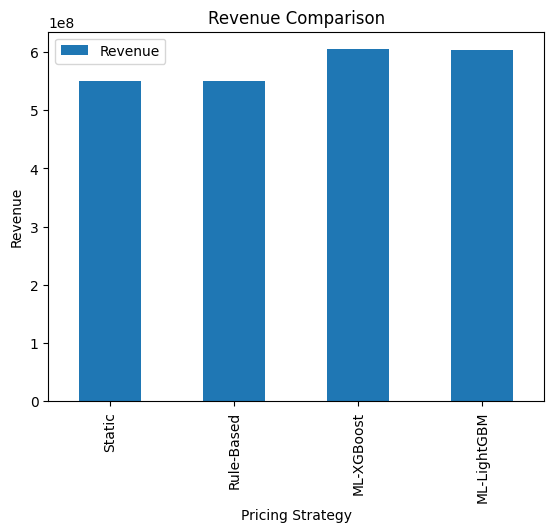

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Pricing Strategy").plot(kind="bar")
plt.title("Revenue Comparison")
plt.ylabel("Revenue")
plt.show()